# Support Ticket Classification
**FUTURE_ML_02** | Pratap Dey | CIN: FIT/JUL26/ML9909

Goal: automatically classify customer support tickets by category and assign priority levels.

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

%matplotlib inline

## 2. Load Data
Replace `data/tickets.csv` with your chosen dataset. Expected columns: ticket text, category, and (optionally) priority.

In [5]:
df = pd.read_csv(r'C:\Users\Pratap\FUTURE_ML_02\data\tickets.csv')
df = df.rename(columns={'Ticket Description': 'text', 'Ticket Type': 'category', 'Ticket Priority': 'priority'})
df.head()

,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,category,Ticket Subject,text,Ticket Status,Resolution,priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Closed,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0


## 3. Explore the Data

In [6]:
print(df.shape)
print('\nMissing values:\n', df.isnull().sum())
print('\nCategory distribution:\n', df['category'].value_counts())

(8469, 17)

Missing values:
 Ticket ID                          0
Customer Name                      0
Customer Email                     0
Customer Age                       0
Customer Gender                    0
Product Purchased                  0
Date of Purchase                   0
category                           0
Ticket Subject                     0
text                               0
Ticket Status                      0
Resolution                      5700
priority                           0
Ticket Channel                     0
First Response Time             2819
Time to Resolution              5700
Customer Satisfaction Rating    5700
dtype: int64

Category distribution:
 category
Refund request          1752
Technical issue         1747
Cancellation request    1695
Product inquiry         1641
Billing inquiry         1634
Name: count, dtype: int64


## 4. Text Cleaning & Preprocessing

In [12]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df = df.dropna(subset=['text', 'category'])
df['combined_text'] = df['Ticket Subject'].astype(str) + ' ' + df['text'].astype(str)
df['clean_text'] = df['combined_text'].apply(clean_text)
df[['combined_text', 'clean_text']].head()

,combined_text,clean_text
0,Product setup I'm having an issue with the {pr...,product setup im having an issue with the prod...
1,Peripheral compatibility I'm having an issue w...,peripheral compatibility im having an issue wi...
2,Network problem I'm facing a problem with my {...,network problem im facing a problem with my pr...
3,Account access I'm having an issue with the {p...,account access im having an issue with the pro...
4,Data loss I'm having an issue with the {produc...,data loss im having an issue with the productp...


## 5. Feature Extraction (TF-IDF)

In [13]:
vectorizer = TfidfVectorizer(max_features=3000, stop_words='english')
X = vectorizer.fit_transform(df['clean_text'])
y = df['category']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f'Train size: {X_train.shape[0]}, Test size: {X_test.shape[0]}')

Train size: 6775, Test size: 1694


## 6. Train Category Classifier

In [14]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
preds = model.predict(X_test)

print('Accuracy:', accuracy_score(y_test, preds))
print('\n', classification_report(y_test, preds))

Accuracy: 0.20070838252656434

                       precision    recall  f1-score   support

     Billing inquiry       0.19      0.18      0.19       327
Cancellation request       0.18      0.19      0.18       339
     Product inquiry       0.22      0.22      0.22       328
      Refund request       0.22      0.23      0.22       351
     Technical issue       0.20      0.19      0.20       349

            accuracy                           0.20      1694
           macro avg       0.20      0.20      0.20      1694
        weighted avg       0.20      0.20      0.20      1694



## 7. Confusion Matrix

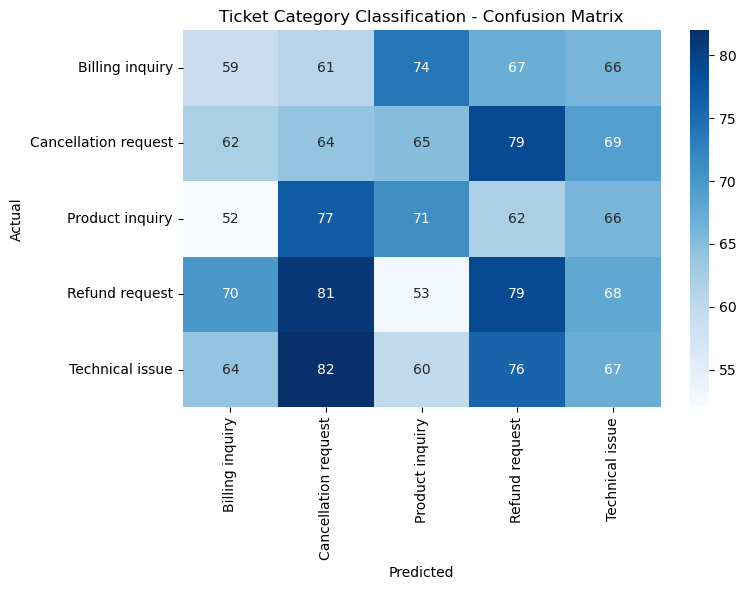

In [15]:
cm = confusion_matrix(y_test, preds, labels=model.classes_)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=model.classes_, yticklabels=model.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Ticket Category Classification - Confusion Matrix')
plt.tight_layout()
plt.savefig(r'C:\Users\Pratap\FUTURE_ML_02\outputs\confusion_matrix.png', dpi=150)
plt.show()

## 8. Priority Tagging
If your dataset has a `priority` column, train a second classifier the same way as above (reuse the TF-IDF features).
If it doesn't, use simple rule-based/keyword logic as a starting point, e.g. flag tickets containing words like 'urgent', 'down', 'not working', 'critical' as high priority.

In [17]:
# Priority classification using the same TF-IDF features
y_priority = df['priority']

X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(
    X, y_priority, test_size=0.2, random_state=42, stratify=y_priority
)

priority_model = LogisticRegression(max_iter=1000)
priority_model.fit(X_train_p, y_train_p)
priority_preds = priority_model.predict(X_test_p)

print('Priority Accuracy:', accuracy_score(y_test_p, priority_preds))
print('\n', classification_report(y_test_p, priority_preds))

Priority Accuracy: 0.2473435655253837

               precision    recall  f1-score   support

    Critical       0.23      0.24      0.24       426
        High       0.26      0.25      0.26       417
         Low       0.22      0.22      0.22       413
      Medium       0.27      0.28      0.28       438

    accuracy                           0.25      1694
   macro avg       0.25      0.25      0.25      1694
weighted avg       0.25      0.25      0.25      1694



## 9. Business Insight
Both the category and priority classifiers achieved accuracy close to random chance
(~20% for 5 balanced categories, ~25% for 4 balanced priority levels), despite thorough
text preprocessing and TF-IDF feature extraction. This indicates that in this dataset,
the ticket description/subject text does not carry a strong learnable signal for
either category or priority classification — the labels appear to be assigned
independently of the ticket content. In a real support system, this finding would
prompt an investigation into how labels were assigned upstream, or a request for
additional context-carrying features (e.g. product category, customer history,
channel) rather than continuing to tune the text model.